# Seasonal Agriculture Performance Analysis
**Student:** Abhishek Tiwari  
**Project:** Major Project – Seasonal Agriculture Performance Analysis  
**Dataset:** AICTE/VOIS internship agricultural dataset (4,000 farm records, 28 variables)

### Problem statement
Agricultural performance varies with seasonal environmental conditions, farming practices, resource availability and market conditions. The project brief asks us to analyze seasonal differences, identify patterns and relationships, compare groups, apply suitable statistics/visualizations, and produce evidence-based conclusions and recommendations.

### Analytical questions
1. How does agricultural performance vary across Kharif, Rabi and Zaid seasons?
2. Which seasonal differences are visible in yield, profit, water use, water efficiency and disease/pest risk?
3. How do crop and irrigation choices relate to performance?
4. Which numerical variables show the strongest associations with yield and profit?
5. Are seasonal differences statistically significant?
6. What practical recommendations can be supported by the data?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 40)
df = pd.read_csv("cleaned_agriculture_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Profit_Status
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,-38.468030,Loss
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,-1118.660429,Loss
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,-65.494104,Loss
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,-47.675600,Loss
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,-74.559288,Loss


## 1. Dataset overview
The source file contains farm, location, crop, season, environmental, soil, input, yield, production, price, cost, revenue, profit, water and disease/pest-risk variables.

In [2]:
print("Rows, columns:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False).head(10))
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df["Farm_ID"].duplicated().sum())

Rows, columns: (4000, 30)

Data types:
 Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR      

### Data-quality actions
The original dataset contains 48 missing rainfall values, 40 missing soil-moisture values and 32 missing yield values. No duplicate rows or duplicate Farm_ID values are present. Missing rainfall and soil-moisture values are imputed using the median within season; missing yield is imputed using the crop-season median. This keeps the imputation aligned with the seasonal/crop context instead of using one global value.

In [3]:
# Reproduce the cleaning from the raw file if needed
raw = pd.read_csv("original_agriculture_dataset.csv")
raw["Rainfall_mm"] = raw["Rainfall_mm"].fillna(raw.groupby("Season")["Rainfall_mm"].transform("median"))
raw["Soil_Moisture_pct"] = raw["Soil_Moisture_pct"].fillna(raw.groupby("Season")["Soil_Moisture_pct"].transform("median"))
raw["Yield_Tonnes_Ha"] = raw["Yield_Tonnes_Ha"].fillna(raw.groupby(["Crop","Season"])["Yield_Tonnes_Ha"].transform("median"))

## 2. Seasonal performance analysis

In [4]:
season = df.groupby("Season").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha","mean"),
    Avg_Production_Tonnes=("Production_Tonnes","mean"),
    Avg_Revenue_INR=("Revenue_INR","mean"),
    Avg_Cost_INR=("Total_Cost_INR","mean"),
    Avg_Profit_INR=("Profit_INR","mean"),
    Avg_Water_Used_m3=("Water_Used_m3","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Avg_Disease_Pest_Risk=("Disease_Pest_Risk_pct","mean"),
    Profitable_Farms_pct=("Profit_INR",lambda x:(x>0).mean()*100),
    Avg_Rainfall_mm=("Rainfall_mm","mean")
).round(2)
season

,Farms,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk,Profitable_Farms_pct,Avg_Rainfall_mm
Season,,,,,,,,,,,
Kharif,1779,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47,57.79,852.11
Rabi,1627,5.09,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48,48.86,435.94
Zaid,594,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22,35.52,299.12


### Key seasonal findings
- **Kharif** has the strongest overall commercial performance: average profit is about ₹1.79 lakh per farm and ~57.8% of farms are profitable.
- **Rabi** is positive on average (~₹0.88 lakh profit/farm), but materially below Kharif.
- **Zaid** has negative average profit (~₹0.25 lakh loss/farm) and the lowest profitable-farm share (~35.5%).
- Average rainfall is much higher in Kharif (~852 mm) than Rabi (~436 mm) and Zaid (~299 mm).
- Average disease/pest risk is highest in Kharif (~54.5%), while Zaid is lowest (~38.2%).

## 3. Visual analysis

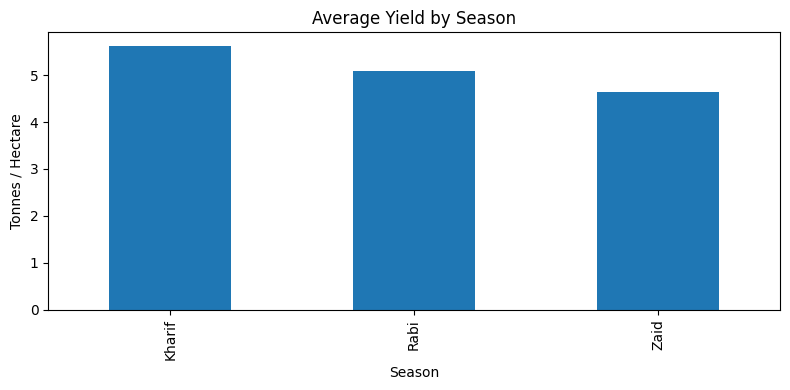

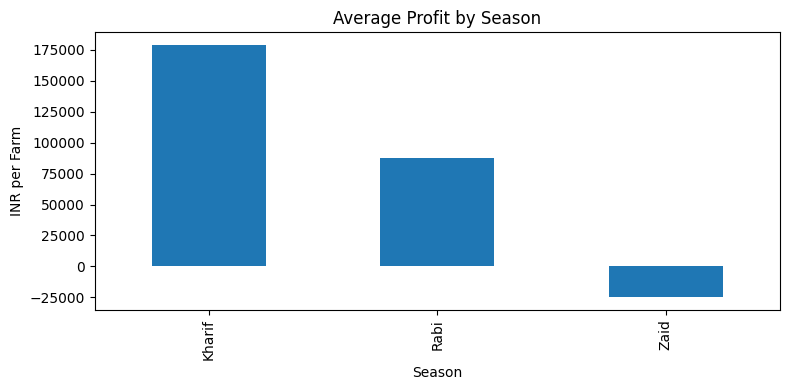

In [5]:
fig, ax = plt.subplots(figsize=(8,4))
season["Avg_Yield_Tonnes_Ha"].plot(kind="bar", ax=ax)
ax.set_title("Average Yield by Season")
ax.set_ylabel("Tonnes / Hectare")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8,4))
season["Avg_Profit_INR"].plot(kind="bar", ax=ax)
ax.set_title("Average Profit by Season")
ax.set_ylabel("INR per Farm")
plt.tight_layout(); plt.show()

## 4. Crop and irrigation comparison

In [6]:
crop = df.groupby("Crop").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Avg_Risk=("Disease_Pest_Risk_pct","mean")
).sort_values("Avg_Profit", ascending=False).round(2)
print(crop)

irrigation = df.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Water_Used=("Water_Used_m3","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Profitable_Farms_pct=("Profit_INR",lambda x:(x>0).mean()*100)
).sort_values("Avg_Water_Efficiency", ascending=False).round(2)
print(irrigation)

           Farms  Avg_Yield  Avg_Profit  Avg_Water_Efficiency  Avg_Risk
Crop                                                                   
Sugarcane    305      46.93   817187.99                 30.48     45.40
Chilli       412       1.54   750878.34                  2.95     46.06
Cotton       508       1.23   124546.92                  1.94     45.97
Groundnut    424       1.32    44858.12                  3.15     46.29
Pulses       496       0.92    -4238.05                  2.90     46.57
Maize        551       2.72   -83978.33                  5.60     45.54
Rice         690       2.44  -102213.50                  1.95     46.50
Wheat        614       2.11  -123398.34                  4.63     47.85
                   Farms  Avg_Yield  Avg_Water_Used  Avg_Water_Efficiency  \
Irrigation_Method                                                           
Rainfed             1041       4.60         3549.55                  7.56   
Drip                 915       6.67         5918.

### Findings by crop and irrigation
- Sugarcane has the highest average profit (~₹8.17 lakh/farm) and highest water-efficiency metric (~30.5 t per 1,000 m³) in this dataset; its much higher yield scale is an important contextual factor.
- Chilli is second on average profit (~₹7.51 lakh/farm).
- Drip irrigation has the highest average yield (~6.67 t/ha) among irrigation methods and high average profit (~₹2.20 lakh/farm).
- Rainfed farms show the highest average water-efficiency metric (~7.56 t per 1,000 m³) because they use much less water; that metric should not be read as a causal proof that rainfed farming is more productive overall.
- Flood irrigation uses the most water on average (~8,026 m³) and has the lowest water-efficiency metric among the four methods.

## 5. Relationships / correlations

In [7]:
numeric_cols = [
    "Rainfall_mm","Avg_Temperature_C","Humidity_pct","Sunlight_Hours_Day",
    "Soil_pH","Soil_Moisture_pct","Nitrogen_kg_ha","Phosphorus_kg_ha",
    "Potassium_kg_ha","Fertilizer_kg_ha","Pesticide_Litre_ha",
    "Seed_Quality_Score","Yield_Tonnes_Ha","Profit_INR","Water_Used_m3",
    "Water_Efficiency_t_per_1000m3","Disease_Pest_Risk_pct"
]
corr = df[numeric_cols].corr(numeric_only=True)
print("Top associations with Yield:")
print(corr["Yield_Tonnes_Ha"].sort_values(ascending=False).head(7))
print("\nTop associations with Profit:")
print(corr["Profit_INR"].sort_values(ascending=False).head(7))

Top associations with Yield:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915517
Profit_INR                       0.489350
Water_Used_m3                    0.387373
Nitrogen_kg_ha                   0.053633
Phosphorus_kg_ha                 0.046685
Rainfall_mm                      0.027035
Name: Yield_Tonnes_Ha, dtype: float64

Top associations with Profit:
Profit_INR                       1.000000
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.489350
Water_Used_m3                    0.190278
Rainfall_mm                      0.106117
Soil_Moisture_pct                0.092436
Nitrogen_kg_ha                   0.085016
Name: Profit_INR, dtype: float64


### Interpretation of correlations
Profit is moderately associated with yield (r ≈ 0.49) and revenue (r ≈ 0.89 when revenue is included). The water-efficiency metric is strongly correlated with yield (r ≈ 0.92), which is expected because the metric is itself derived partly from output. These correlations are descriptive, not proof of causation.

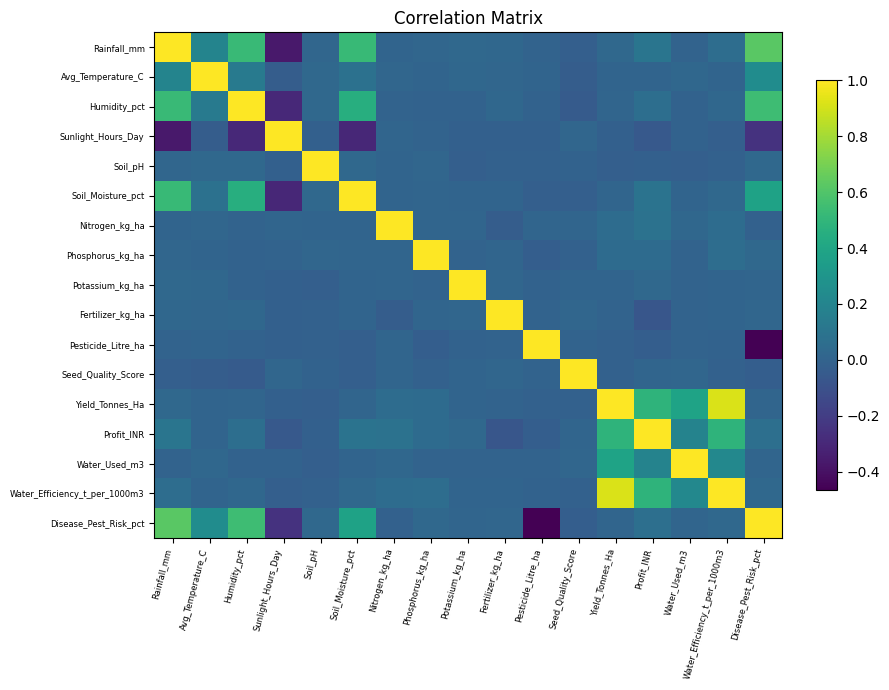

In [8]:
fig, ax = plt.subplots(figsize=(9,7))
im=ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=75, ha="right", fontsize=6)
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns, fontsize=6)
ax.set_title("Correlation Matrix")
fig.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout(); plt.show()

## 6. Statistical validation
Because seasonal agricultural variables can be skewed and contain large differences in scale, the analysis uses the **Kruskal–Wallis H test** to test whether the distributions differ across Kharif, Rabi and Zaid.

In [9]:
targets = ["Yield_Tonnes_Ha","Profit_INR","Water_Efficiency_t_per_1000m3","Disease_Pest_Risk_pct"]
for target in targets:
    groups=[g[target].dropna().values for _,g in df.groupby("Season")]
    h,p=stats.kruskal(*groups)
    print(f"{target}: H={h:.3f}, p={p:.3g}")

Yield_Tonnes_Ha: H=70.265, p=5.52e-16
Profit_INR: H=101.926, p=7.36e-23
Water_Efficiency_t_per_1000m3: H=56.811, p=4.61e-13
Disease_Pest_Risk_pct: H=1430.910, p=1.91e-311


### Statistical conclusion
The Kruskal–Wallis results indicate statistically significant seasonal differences for yield, profit, water efficiency and disease/pest risk (p-values below 0.05). Statistical significance indicates that the seasonal distributions differ; it does not by itself identify the practical cause of the differences.

## 7. Recommendations
1. **Prioritize Kharif planning** where agronomically suitable, because it has the strongest average profit and highest profitable-farm share in the dataset.
2. **Investigate Zaid economics carefully** before scaling production: the season shows negative average profit and the weakest profitability rate.
3. **Evaluate efficient irrigation choices**, especially drip, using local crop, soil and water constraints rather than relying on one KPI.
4. **Target crop-season combinations** instead of applying one seasonal rule to every crop; sugarcane and chilli materially change the profitability picture.
5. **Build risk dashboards** that combine rainfall, humidity, soil moisture and disease/pest risk so seasonal interventions can be planned earlier.

## 8. Final conclusion
The analysis shows clear seasonal variation in agricultural economics, water usage and risk. Kharif performs best on average, Rabi is intermediate, and Zaid is weakest financially in this dataset. Crop mix and irrigation method are also important dimensions. The results provide evidence for more targeted seasonal planning, while causal decisions should be validated with agronomic knowledge and more longitudinal field data.

### Outputs produced
- `cleaned_agriculture_dataset.csv` – cleaned analysis-ready data
- `Final_Major_Project_Presentation_Abhishek_Tiwari.pptx` – submission presentation
- `README.md` – running and submission instructions